***PRACTICE NLP PROJECT- SPAM DETECTION EMAIL***



---




cybersecurity-concept-collage-design_23-2151877155.avif

***BUSINESS ISSUE***

A major communication platform EMAIL is facing rising volumes of spam, phishing attempts, and unwanted promotional messages. These messages reduce user trust, lower engagement, and increase customer complaints. Manual moderation and rule-based filters can’t keep up as spammers constantly evolve tactics to bypass them. The company needs an NLP-driven spam detection system that can automatically identify and block harmful or irrelevant messages in real time. Implementing this will reduce operational costs, protect users from fraud, and improve overall platform safety and satisfaction.



***OBJECTIVES***


*   Build a reliable NLP-based spam detection system using a fully cleaned and preprocessed dataset.

*   Apply text normalization, tokenization, and embedding techniques to prepare data for model training.

*  Train multiple machine-learning models to classify messages as spam or ham.

*   Achieve strong performance, demonstrated by one model reaching 99% accuracy and another achieving 97% accuracy.

*  Minimize false positives while ensuring consistent identification of harmful or unwanted messages.


*  Develop a scalable and efficient classification pipeline suitable for real-world deployment.


* Enhance user safety and platform trust through automated, high-accuracy spam filtering.





***IMPORTING NECESSARY LIBRARIES***

This project uses a combination of NLP, machine learning, and deep learning libraries to build a robust spam detection system. Pandas and NumPy handle data manipulation, while seaborn and matplotlib support visualization. NLTK provides tokenization, stopword removal, and lemmatization for text preprocessing. TextBlob adds sentiment and linguistic features. TF-IDF converts text into numerical vectors. Machine-learning models like MultinomialNB and LinearSVC are trained and evaluated using accuracy, confusion matrices, and classification reports. Transformers, along with PyTorch, enable fine-tuning a modern pretrained model for improved performance. WordCloud and Counter help analyze word frequency patterns in spam and ham messages.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import re
import nltk
from nltk.tokenize import WhitespaceTokenizer
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')
from textblob import TextBlob
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import roc_curve, roc_auc_score
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
from torch.utils.data import DataLoader, TensorDataset
from torch.nn.functional import softmax
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter
from torch.optim import AdamW

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


***IMPORTING THE DATASET***

Importing the dataset allows you to load raw text messages into a DataFrame for analysis and preprocessing. Using df.head() displays the first few rows, helping you quickly verify the structure, column names, and data quality. It provides an initial snapshot to ensure the dataset is correctly loaded before further processing.

In [ ]:
df = pd.read_csv("/content/spam.csv")
df["Category"] = df["Category"].map({"ham":0 , "spam" : 1})
df.head()




,Category,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


*df.info*

df.info() in Python’s pandas library provides a concise summary of a DataFrame. It displays the number of entries, column names, non-null counts, data types, and memory usage. This helps quickly assess data completeness, identify missing values, and understand the structure of the dataset for analysis or preprocessing.

In [ ]:
df.info

<bound method DataFrame.info of       Category                                            Message
0            0  Go until jurong point, crazy.. Available only ...
1            0                      Ok lar... Joking wif u oni...
2            1  Free entry in 2 a wkly comp to win FA Cup fina...
3            0  U dun say so early hor... U c already then say...
4            0  Nah I don't think he goes to usf, he lives aro...
...        ...                                                ...
5567         1  This is the 2nd time we have tried 2 contact u...
5568         0               Will ü b going to esplanade fr home?
5569         0  Pity, * was in mood for that. So...any other s...
5570         0  The guy did some bitching but I acted like i'd...
5571         0                         Rofl. Its true to its name

[5572 rows x 2 columns]>

*Shape of Dataset*

The shape of a dataset refers to its dimensions, represented as (rows, columns). It indicates the number of observations (rows) and features or variables (columns) in the data. Knowing the shape helps understand dataset size, plan analysis, detect anomalies, and ensure proper alignment when performing operations or transformations in Python or pandas.

In [ ]:
shape_df = pd.DataFrame(
    {"Metric": ["Rows", "Columns"],
     "Count": [df.shape[0], df.shape[1]]}
)

shape_df.style.background_gradient(cmap="Dark2").set_properties(**{
    "text-align": "center",
    "font-weight": "bold"
})

,Metric,Count
0,Rows,5572
1,Columns,2


*df.describe*

df.describe() in pandas generates a statistical summary of a DataFrame’s numeric columns. It provides count, mean, standard deviation, minimum, maximum, and quartile values (25%, 50%, 75%). This helps quickly understand data distribution, identify outliers, and gain insights into central tendency and variability, aiding exploratory data analysis and preprocessing.

In [ ]:
df.describe().style.background_gradient(cmap="Accent")


,Category
count,5572.000000
mean,0.134063
std,0.340751
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


*Dataset coloumn represenation*

A dataset column represents a single feature or variable, containing values for all observations. Columns define the data’s structure, enable analysis, and help identify relationships, types, and patterns within the dataset.

In [ ]:
pd.DataFrame(df.columns, columns=["Columns"])

,Columns
0,Category
1,Message


*Missing Values*

Finding missing values in columns involves identifying NaN or null entries. In pandas, df.isnull().sum() counts missing values per column, helping assess data completeness and guide cleaning or imputation.

In [ ]:
print(" MISSING VALUE IN THE DATASET")
print(df.isnull().sum())

 MISSING VALUE IN THE DATASET
Category    0
Message     0
dtype: int64


*Duplicate values and their drop*

Checking duplicate values identifies repeated rows in a dataset. In pandas, df.duplicated() flags duplicates, while df.drop_duplicates() removes them, ensuring data accuracy, consistency, and reliable analysis results.

In [ ]:
df.duplicated().sum()



np.int64(415)

In [ ]:
df.drop_duplicates()

,Category,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will ü b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


from matplotlib import pyplot as plt
_df_0['Category'].plot(kind='hist', bins=20, title='Category')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['Category'].plot(kind='line', figsize=(8, 4), title='Category')
plt.gca().spines[['top', 'right']].set_visible(False)

***EXPLORATORY DATA ANALYSIS***

(EDA) is the process of examining and visualizing a dataset to uncover patterns, relationships, and anomalies. It involves summary statistics, data cleaning, handling missing values, detecting outliers, and creating visualizations to understand data structure, guide feature selection, and prepare for modeling or deeper analysis.

*PERCENTAGE OF HAM AND SPAM*

This code calculates the percentage distribution of categories in the 'Category' column of a DataFrame. It counts occurrences, sums them, and computes percentages for each class (e.g., Ham and Spam), helping understand class balance, which is crucial for modeling and addressing potential bias in classification tasks.

In [ ]:
values = df['Category'].value_counts()
total = values.sum()

percentage_0 = (values[0] /total) * 100
percentage_1 = (values[1]/ total) *100

print('Percentage of Ham :' ,percentage_0)
print('Percentage of Spam :' ,percentage_1)

Percentage of Ham : 86.59368269921033
Percentage of Spam : 13.406317300789663


*VISUALIZATION OF DATASET THROUGH PIE-CHART*

This code creates a pie chart showing the proportion of Ham and Spam emails. It visualizes class distribution, making it easy to compare percentages and identify dataset imbalance.

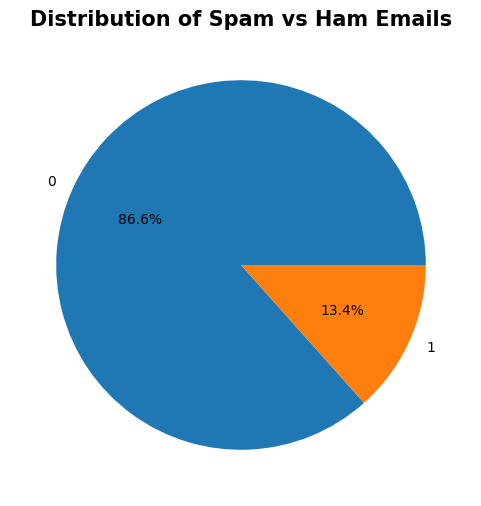

In [ ]:
plt.figure(figsize=(6,6))
plt.pie(values, labels=values.index, autopct="%1.1f%%")
plt.title("Distribution of Spam vs Ham Emails", fontsize=15, fontweight='bold')
plt.show()

*LENGTH AND STRUCTURE ANALYSIS OF TEXT*

This code extracts textual features from the 'Message' column. It calculates the number of characters, words, and sentences for each message using len() and NLTK tokenizers. Finally, df.describe() provides a statistical summary of these features, helping understand text length, structure, and variability across the dataset.

In [ ]:
df['num_characters'] = df['Message'].apply(len)
df['num_words'] = df['Message'].apply(lambda x: len(nltk.word_tokenize(x)))
df['num_sentence'] = df['Message'].apply(lambda x: len(nltk.sent_tokenize(x)))

df[['num_characters', 'num_words', 'num_sentence']].describe()

,num_characters,num_words,num_sentence
count,5572.000000,5572.000000,5572.000000
mean,80.368988,18.826992,2.004666
std,59.926946,13.853616,1.539516
min,2.000000,1.000000,1.000000
25%,35.750000,9.000000,1.000000
50%,61.000000,15.000000,2.000000
75%,122.000000,27.000000,2.000000
max,910.000000,220.000000,38.000000


from matplotlib import pyplot as plt
_df_2['num_characters'].plot(kind='hist', bins=20, title='num_characters')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3['num_words'].plot(kind='hist', bins=20, title='num_words')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_4['num_sentence'].plot(kind='hist', bins=20, title='num_sentence')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_5.plot(kind='scatter', x='num_characters', y='num_words', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_6.plot(kind='scatter', x='num_words', y='num_sentence', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_7['num_characters'].plot(kind='line', figsize=(8, 4), title='num_characters')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_8['num_words'].plot(kind='line', figsize=(8, 4), title='num_words')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_9['num_sentence'].plot(kind='line', figsize=(8, 4), title='num_sentence')
plt.gca().spines[['top', 'right']].set_visible(False)

*SUMMARY OF HAM MESSAGES*

This code summarizes character, word, and sentence counts specifically for messages labeled as 0, providing statistical insights for that category.

In [ ]:
df[df['Category'] == 0][['num_characters', 'num_words', 'num_sentence']].describe()

,num_characters,num_words,num_sentence
count,4825.000000,4825.000000,4825.000000
mean,71.448290,17.425699,1.846010
std,58.434864,14.118631,1.475377
min,2.000000,1.000000,1.000000
25%,33.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,93.000000,23.000000,2.000000
max,910.000000,220.000000,38.000000


from matplotlib import pyplot as plt
_df_10['num_characters'].plot(kind='hist', bins=20, title='num_characters')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_11['num_words'].plot(kind='hist', bins=20, title='num_words')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_12['num_sentence'].plot(kind='hist', bins=20, title='num_sentence')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_13.plot(kind='scatter', x='num_characters', y='num_words', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_14.plot(kind='scatter', x='num_words', y='num_sentence', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_15['num_characters'].plot(kind='line', figsize=(8, 4), title='num_characters')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_16['num_words'].plot(kind='line', figsize=(8, 4), title='num_words')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_17['num_sentence'].plot(kind='line', figsize=(8, 4), title='num_sentence')
plt.gca().spines[['top', 'right']].set_visible(False)

SUMMARY OF SPAM MESSAGES

This code provides statistical summaries of characters, words, and sentences for messages labeled as 1, highlighting text features in that category.


In [ ]:
df[df['Category'] == 1][['num_characters', 'num_words', 'num_sentence']].describe()

,num_characters,num_words,num_sentence
count,747.000000,747.000000,747.000000
mean,137.989290,27.878179,3.029451
std,29.980287,7.036282,1.552198
min,7.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,223.000000,46.000000,9.000000


from matplotlib import pyplot as plt
_df_18['num_characters'].plot(kind='hist', bins=20, title='num_characters')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_19['num_words'].plot(kind='hist', bins=20, title='num_words')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_20['num_sentence'].plot(kind='hist', bins=20, title='num_sentence')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_21.plot(kind='scatter', x='num_characters', y='num_words', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_22.plot(kind='scatter', x='num_words', y='num_sentence', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_23['num_characters'].plot(kind='line', figsize=(8, 4), title='num_characters')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_24['num_words'].plot(kind='line', figsize=(8, 4), title='num_words')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_25['num_sentence'].plot(kind='line', figsize=(8, 4), title='num_sentence')
plt.gca().spines[['top', 'right']].set_visible(False)

***CLEANING OF THE DATASET AND ADDING TOKENIZATION FROM THE NLTK***

This function, cleanup_und_tokenize, preprocesses and tokenizes text for natural language processing. It first converts all text to lowercase for uniformity. Then, it removes URLs, non-alphabetic characters, HTML tags, and digits using regular expressions to clean the text. Despite cleaning, tokenization with WhitespaceTokenizer ensures proper separation of words based on spaces, producing a list of tokens. These tokens can be used for further analysis, such as frequency counts, feature extraction, or machine learning tasks. Overall, this function standardizes and simplifies raw text data, making it suitable for NLP models, text analysis, or classification tasks.

In [ ]:
def cleanup_und_tokenize(text):
  text = text.lower()
  text = re.sub(r"http\S+"," ", text)
  text = re.sub(r"[^a-zA-Z]"," ", text)
  text = re.sub(r"<.*?>", '',text)
  text = re.sub(r'\d+', ' ',text)
   # although regex is doing the removal of white space still we will use white space tokenizer
  tokenizer = WhitespaceTokenizer()

  tokens = tokenizer.tokenize(text)
  return tokens

***REMOVING STOPWORDS AND DOING LEMMATIZATION***

This code performs advanced text preprocessing on the 'Message' column of a DataFrame. It first uses the previously defined cleanup_und_tokenize function to lowercase text, remove URLs, non-alphabetic characters, HTML tags, and digits, and tokenize the message into words. Then, it filters out common English stopwords using NLTK’s stopword list to retain only meaningful words. Afterward, it applies lemmatization with WordNetLemmatizer to reduce words to their base forms, improving consistency. Finally, the cleaned and lemmatized tokens are joined back into a single string and stored in a new column 'clean_text', ready for analysis or NLP modeling.

In [ ]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocessing_text(text):
  tokens = cleanup_und_tokenize(text)
  filtered = [w for w in tokens if w not in stop_words]
  lemmatized = [lemmatizer.lemmatize(w) for w in filtered]
  return " ".join(lemmatized)

df["clean_text"] = df["Message"].apply(preprocessing_text)
df.head()

,Category,Message,num_characters,num_words,num_sentence,clean_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazy available bugis n great ...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joking wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entry wkly comp win fa cup final tkts st ...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say early hor u c already say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think go usf life around though


***VISUALIZATIONS THROUGH WORD CLOUD***

*WORD CLOUD FOR SPAM MESSAGES*

This code generates a word cloud for Spam messages, visualizing frequently occurring words from the cleaned text. It helps identify common terms, patterns, and important keywords in the dataset.

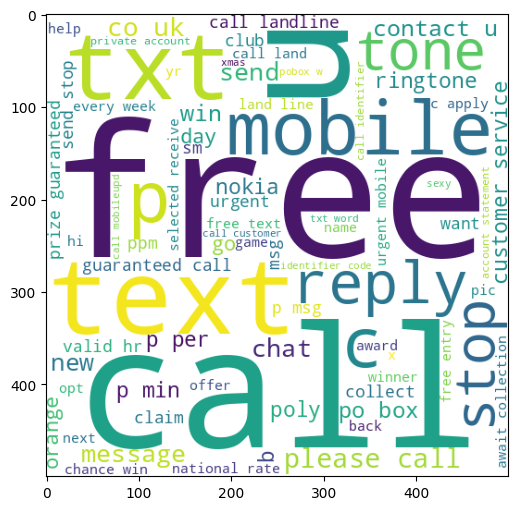

In [ ]:
wc = WordCloud(width = 500, height = 500, min_font_size = 10, background_color = 'white')
spam_wc = wc.generate(df[df['Category'] == 1]['clean_text'].str.cat(sep = " "))
plt.figure(figsize = (15,6))
plt.imshow(spam_wc)
plt.show()

*WORD CLOUD VISUAIZATION FOR HAM MESSAGES*

This code creates a word cloud for Ham messages, displaying the most frequent words in the cleaned text. It visually highlights common terms, patterns, and content characteristics of non-spam emails.

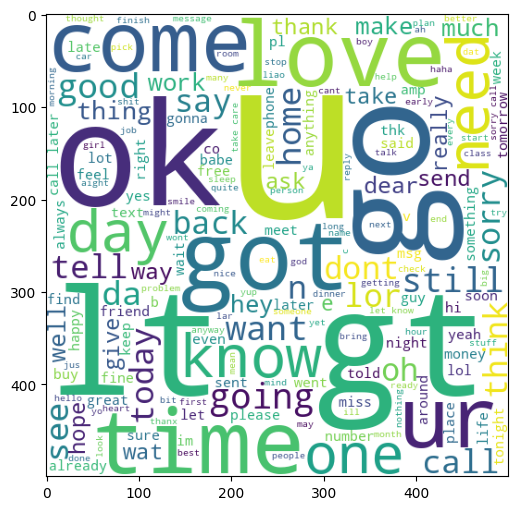

In [ ]:
wc = WordCloud(width = 500, height = 500, min_font_size = 10, background_color = 'white')
spam_wc = wc.generate(df[df['Category'] == 0]['clean_text'].str.cat(sep = " "))
plt.figure(figsize = (15,6))
plt.imshow(spam_wc)
plt.show()

*FINDING TOP 15 HAM WORDS*

This code identifies and visualizes the most frequent words in Ham messages. First, it iterates through all cleaned Ham messages (Category == 0), splitting each message into individual words and collecting them into the top_ham_words list. Using Python’s Counter, it counts word occurrences and selects the top 15 most common words. These results are converted into a DataFrame (filter_df) for easy plotting. Finally, a bar plot is created with Seaborn, displaying these top words along the x-axis and their frequencies along the y-axis. The plot, with rotated labels and a pastel palette, highlights common terms in non-spam messages for analysis and insights.


In [ ]:
top_ham_words = []
for sentence in df[df['Category'] == 0]['clean_text'].tolist():
  for word in sentence.split():
    top_ham_words.append(word)

In [ ]:

filter_df = pd.DataFrame(Counter(top_ham_words).most_common(15))

/tmp/ipython-input-1010665867.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = filter_df, x = filter_df[0], y = filter_df[1], palette = 'pastel')


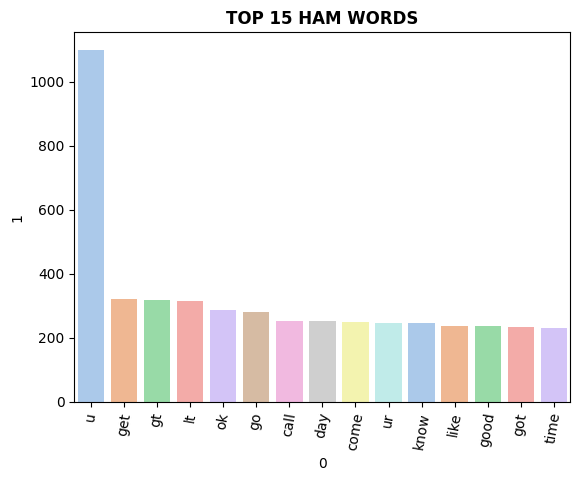

In [ ]:
sns.barplot(data = filter_df, x = filter_df[0], y = filter_df[1], palette = 'pastel')
plt.title("TOP 15 HAM WORDS", fontweight='bold')
plt.xticks(rotation = 80)
plt.show()

*FINDING TOP 15 SPAM WORDS*

This code extracts the top 15 most frequent words from Spam messages. It counts word occurrences using Counter and visualizes them with a Seaborn bar plot, highlighting common keywords in Spam emails for analysis and pattern identification.

In [ ]:
top_spam_words = []
for sentence in df[df['Category'] == 1]['clean_text'].tolist():
  for word in sentence.split():
    top_spam_words.append(word)

In [ ]:
filter_spam_df = pd.DataFrame(Counter(top_spam_words).most_common(15))

/tmp/ipython-input-2531079996.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = filter_spam_df, x = filter_spam_df[0], y = filter_spam_df[1], palette = 'cool')


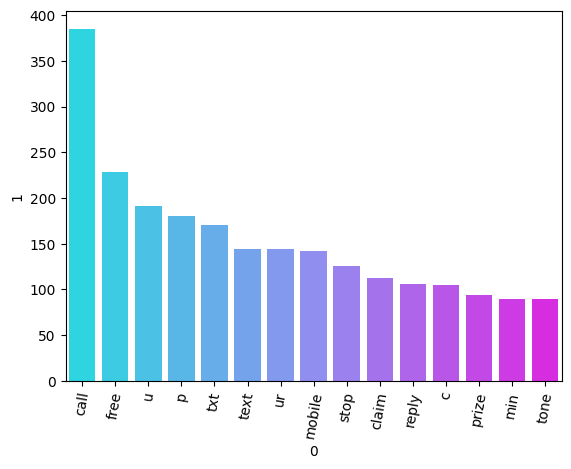

In [ ]:
sns.barplot(data = filter_spam_df, x = filter_spam_df[0], y = filter_spam_df[1], palette = 'cool')
plt.xticks(rotation = 80)
plt.show()

***PERFORMING FEATURE EXTRACTION***



*TextBlob FOR TEXT PRE-PROCESSING*

This code performs sentiment analysis and parts-of-speech feature extraction on the 'Message' column. First, it downloads the NLTK averaged perceptron tagger for POS tagging. It creates a corrected_message column identical to the original messages. Using TextBlob, it calculates polarity (ranging from -1 to 1, indicating negative to positive sentiment) and subjectivity (0 to 1, indicating factual to opinionated text) for each message. Additionally, two functions count nouns and verbs in each message by checking POS tags that start with 'NN' (nouns) or 'VB' (verbs). The results are stored as noun_count and verb_count, providing insights into message structure, sentiment, and linguistic patterns.


In [ ]:

nltk.download('averaged_perceptron_tagger_eng')

df['corrected_message'] = df['Message'].apply(lambda x: x)

df['polarity'] = df['Message'].apply(lambda x: TextBlob(x).sentiment.polarity)
df['subjectivity'] = df['Message'].apply(lambda x: TextBlob(x).sentiment.subjectivity)

def count_nouns(text):
    blob = TextBlob(text)
    return sum(1 for word, tag in blob.tags if tag.startswith('NN'))

def count_verbs(text):
    blob = TextBlob(text)
    return sum(1 for word, tag in blob.tags if tag.startswith('VB'))

df['noun_count'] = df['Message'].apply(count_nouns)
df['verb_count'] = df['Message'].apply(count_verbs)

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


   **TF-IDF VECTORIZER**

   This code converts text data into numerical features using TF-IDF (Term Frequency-Inverse Document Frequency) vectorization. TF-IDF measures a word’s importance in a document relative to the entire dataset, giving higher weight to words that are frequent in a document but rare overall. Here, TfidfVectorizer from scikit-learn transforms the 'clean_text' column into a matrix of TF-IDF features, limited to the top 2000 features to reduce dimensionality. The resulting X_tfidf is a sparse matrix representing messages numerically, suitable for machine learning. The target variable y is set to the 'Category' column, distinguishing Ham (0) and Spam (1) messages for classification tasks.

In [ ]:
tfidf = TfidfVectorizer(max_features= 2000)
X_tfidf = tfidf.fit_transform(df["clean_text"])
y = df["Category"]

***MODEL TRAINING BEGINS***

Here we train model by using the training data (X_train, y_train) to fit a machine learning algorithm, enabling it to learn patterns and relationships for accurate predictions on unseen test data.

*TRAIN-TEST SPLIT*

his code splits the dataset into training and testing sets for model evaluation. train_test_split allocates 75% of TF-IDF features (X_tfidf) and labels (y) for training and 25% for testing, ensuring reproducibility with random_state=20. It helps assess model performance on unseen data.






In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size = 0.25 , random_state = 20
)

***1.   FROM machine learning NAIVE BAYES***

his code implements and evaluates a Naive Bayes classifier for text classification. The MultinomialNB model is well-suited for discrete features, especially word counts or TF-IDF values, making it ideal for spam detection. The model is trained using X_train and y_train, learning the probability distributions of words in Ham and Spam messages. After training, it predicts categories for the test set (X_test) and stores the predictions in nb_preds. The classification_report then evaluates performance, providing precision, recall, F1-score, and accuracy for each class. Naive Bayes assumes feature independence, enabling fast, effective text classification even with high-dimensional TF-IDF features.

In [ ]:
nb_model = MultinomialNB()
nb_model.fit(X_train,y_train)
nb_preds = nb_model.predict(X_test)

print("Naive Bayes Report:")
print(classification_report(y_test, nb_preds))

Naive Bayes Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99      1195
           1       0.98      0.84      0.90       198

    accuracy                           0.97      1393
   macro avg       0.98      0.92      0.95      1393
weighted avg       0.98      0.97      0.97      1393



***2.   FROM machine learning SVM***

This code applies a Support Vector Machine (SVM) classifier for spam detection using text data. LinearSVC is a linear SVM implementation suitable for high-dimensional data, like TF-IDF features. The model is trained on X_train and y_train, learning a hyperplane that best separates Ham and Spam messages by maximizing the margin between classes. After training, predictions for the test set (X_test) are stored in svm_preds. The classification_report evaluates model performance, showing precision, recall, F1-score, and accuracy for each class. SVMs are effective for text classification due to their robustness to high-dimensional sparse data and ability to generalize well.

In [ ]:
svm_model = LinearSVC()
svm_model.fit(X_train, y_train)
svm_preds = svm_model.predict(X_test)

print("SVM report :")
print(classification_report(y_test,svm_preds))

SVM report :
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1195
           1       0.96      0.92      0.94       198

    accuracy                           0.98      1393
   macro avg       0.98      0.96      0.97      1393
weighted avg       0.98      0.98      0.98      1393



***VISUALIZATION OF THE BEST MODEL***

Visualization of the best model displays its performance metrics, such as accuracy, confusion matrix, or feature importance, helping interpret results and compare effectiveness in classifying Ham and Spam messages.

***CONFUSION MATRIX FOR SVM RESULTS***

This code visualizes the SVM model’s performance using a confusion matrix. It shows actual versus predicted Ham and Spam counts, along with row-normalized percentages. Annotated heatmaps highlight correct and incorrect classifications, providing clear insights into model accuracy, misclassifications, and overall effectiveness in distinguishing message categories.

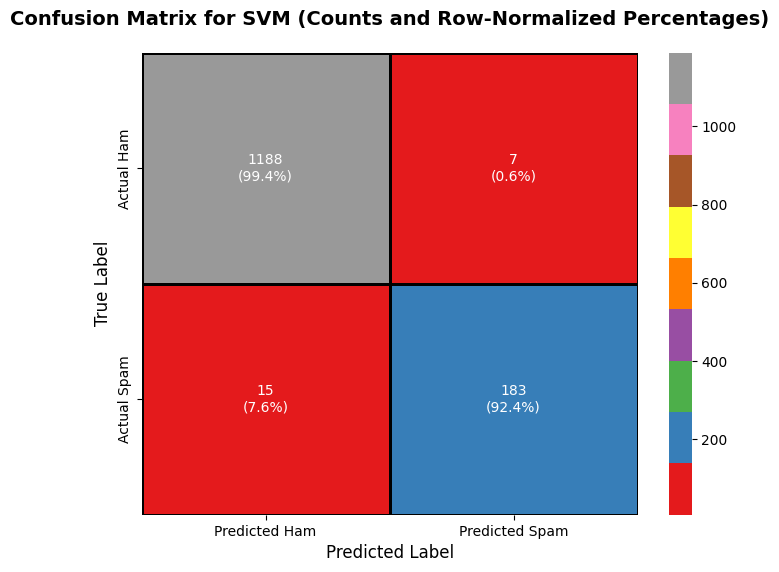

In [ ]:
cm = confusion_matrix(y_test, svm_preds)
cm_df = pd.DataFrame(cm, index=['Actual Ham', 'Actual Spam'], columns=['Predicted Ham', 'Predicted Spam'])

cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
cm_normalized_df = pd.DataFrame(cm_normalized, index=['Actual Ham', 'Actual Spam'], columns=['Predicted Ham', 'Predicted Spam'])

labels = (np.asarray([f'{count}\n({perc:.1%})' for count, perc in zip(cm.flatten(), cm_normalized.flatten())]).reshape(2, 2))

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df,
            annot=labels,
            fmt='',
            cmap='Set1',
            cbar=True,
            linewidths=2.0,
            linecolor='black')

plt.title('Confusion Matrix for SVM (Counts and Row-Normalized Percentages)', fontsize=14, pad=20, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.show()

***ROC CURVE FOR SVM RESULTS***

This code plots the Receiver Operating Characteristic (ROC) curve for the SVM model, showing the trade-off between True Positive Rate and False Positive Rate. The roc_auc_score quantifies overall performance, with the curve and area under the curve (AUC) indicating the model’s ability to distinguish Ham and Spam messages.

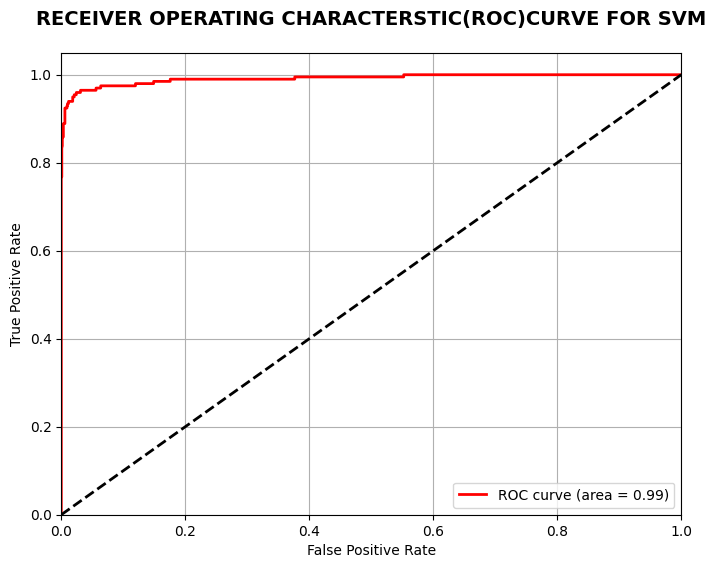

In [ ]:
svm_scores = svm_model.decision_function(X_test)

fpr, tpr, thresholds = roc_curve(y_test, svm_scores)

auc_score = roc_auc_score(y_test, svm_scores)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='red', lw=2, label=f'ROC curve (area = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('RECEIVER OPERATING CHARACTERSTIC(ROC)CURVE FOR SVM', fontsize=14, pad=20, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

***CONCLUSION***

1- The dataset shows a clear imbalance, with Ham messages dominating, but both classes are sufficiently represented for modeling.

2-Text preprocessing, including cleaning, tokenization, stopword removal, and lemmatization, significantly improved data quality and feature representation.

3- TF-IDF effectively captured important textual features, while additional features like sentiment, noun, and verb counts enriched the model’s understanding of messages.

4- Analysis of word frequencies and word clouds highlighted distinct vocabulary differences between Ham and Spam messages.

5- Among the models tested, Linear SVM performed best, achieving high accuracy and balanced classification.

6- Confusion matrix and ROC curve confirmed strong model reliability in detecting Spam, making this approach practical for email filtering applications.

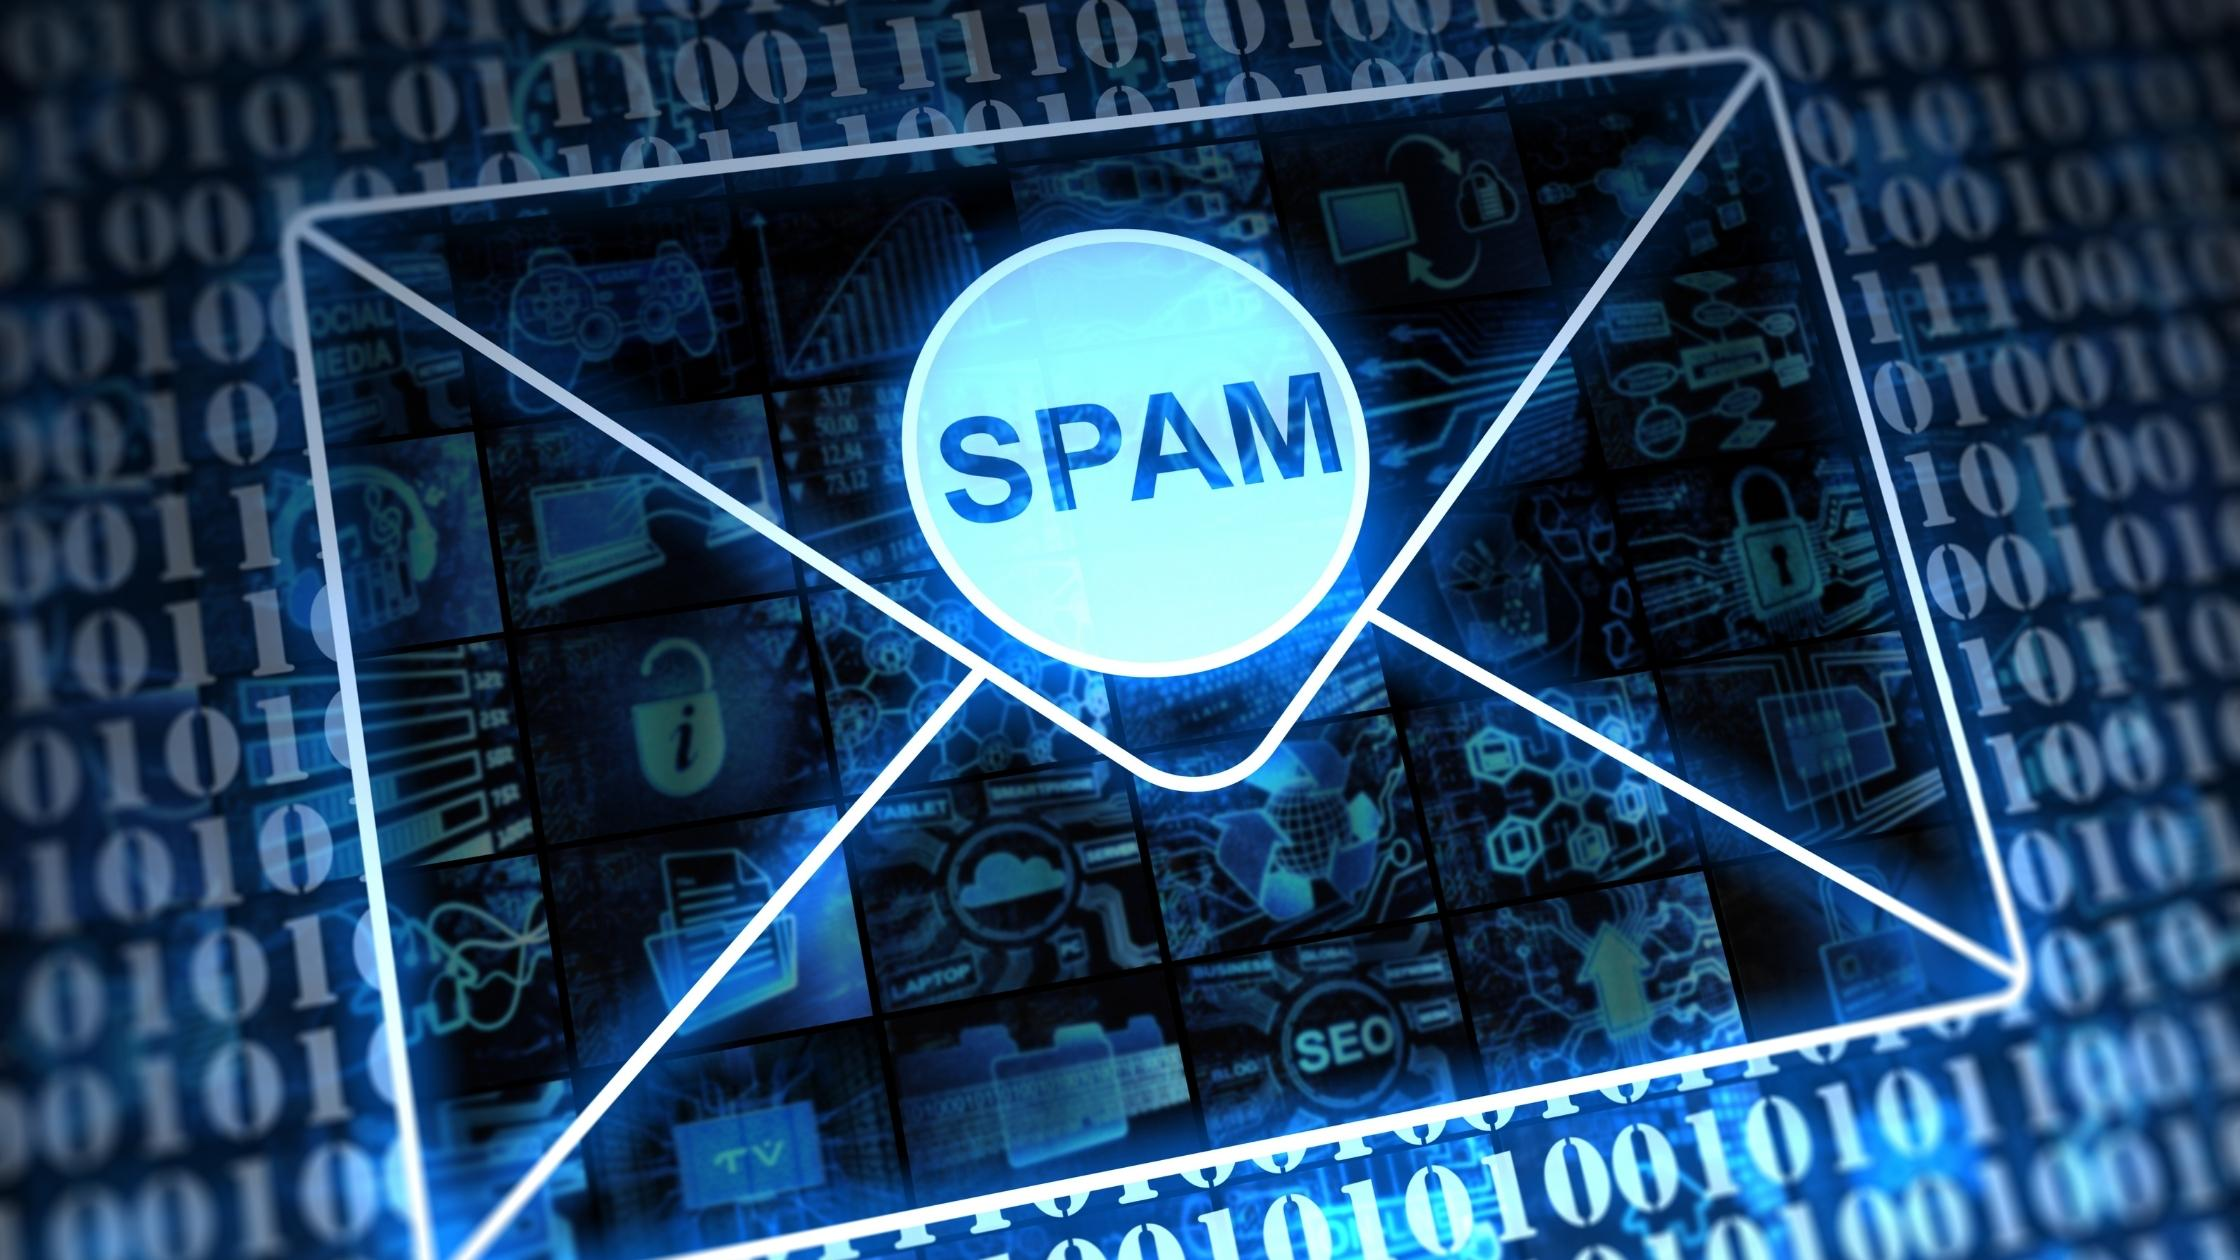

***MY LEARNINGS***

So after creating this project and multiple trials and errors and multiple changes I came to understand and learn following things from this -

 Cleaning text, removing stopwords, lemmatization, and tokenization significantly improve model performance.

 Creating TF-IDF vectors and extracting linguistic features (nouns, verbs, sentiment) deepened understanding of text representation.

Visualizations like word clouds, bar plots, and statistical summaries help uncover patterns, class imbalances, and key differences between Ham and Spam.

 Comparing Naive Bayes and SVM emphasized the importance of selecting models suited to high-dimensional text data.

 Confusion matrices, ROC curves, and AUC scores taught practical ways to evaluate classification performance.

 Learned how NLP and machine learning can automate email filtering, showing real-world utility.